Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


Load CSVs

In [3]:
orders = pd.read_csv("data/olist_orders_dataset.csv")

items = pd.read_csv("data/olist_order_items_dataset.csv")

customers = pd.read_csv("data/olist_customers_dataset.csv")

Inspect the datasets

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Check for missing values/null

In [16]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [18]:
items.isnull().sum()


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [19]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Convert strings to dates

In [20]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

Inner merge orders and items

In [21]:
merged = pd.merge(
    orders,
    items,
    on="order_id",
    how="inner"
)



Inner merge customers 

In [22]:
merged = pd.merge(
    merged,
    customers,
    on="customer_id",
    how="inner"
)

Check the merge

In [23]:
merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


Create columns for month, year, delivery time, and high-value orders

In [24]:
merged["month"] = merged["order_purchase_timestamp"].dt.month_name()




In [25]:
merged["year"] = merged["order_purchase_timestamp"].dt.year



In [26]:
merged["delivery_days"] = (
    merged["order_delivered_customer_date"]
    - merged["order_purchase_timestamp"]
).dt.days


In [27]:
merged["high_value"] = np.where(
    merged["price"] > 100,
    1,
    0
)

Monthly Sales

In [28]:
monthly_sales = (
    merged.groupby("month")["price"]
    .sum()
    .reset_index()
)

monthly_sales

,month,price
0,April,1356574.98
1,August,1428658.01
2,December,743925.07
3,February,1091481.73
4,January,1070343.23
5,July,1393538.70
6,June,1298162.91
7,March,1357557.74
8,May,1502588.82
9,November,1010271.37


State sales

In [30]:
state_sales = (
    merged.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

state_sales.head()

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
Name: price, dtype: float64

Avg delivery time

In [31]:
merged.groupby("customer_state")["delivery_days"].mean()

customer_state
AC    20.329670
AL    23.992974
AM    25.963190
AP    27.753086
BA    18.774640
CE    20.537167
DF    12.501486
ES    15.192809
GO    14.948177
MA    21.203750
MG    11.515522
MS    15.107275
MT    17.508197
PA    23.301708
PB    20.119454
PE    17.792096
PI    18.931166
PR    11.480793
RJ    14.689382
RN    18.873321
RO    19.282051
RR    27.826087
RS    14.708299
SC    14.520986
SE    20.978667
SP     8.259609
TO    17.003226
Name: delivery_days, dtype: float64

RFM Analysis

In [32]:
snapshot_date = merged["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

In [33]:
rfm = merged.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,
    "order_id": "nunique",
    "price": "sum"
})

In [34]:
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [35]:
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
0000f46a3911fa3c0805444483337064,542,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
0004aac84e0df4da2b147fca70cf8255,293,1,180.00


Monthly sales plot

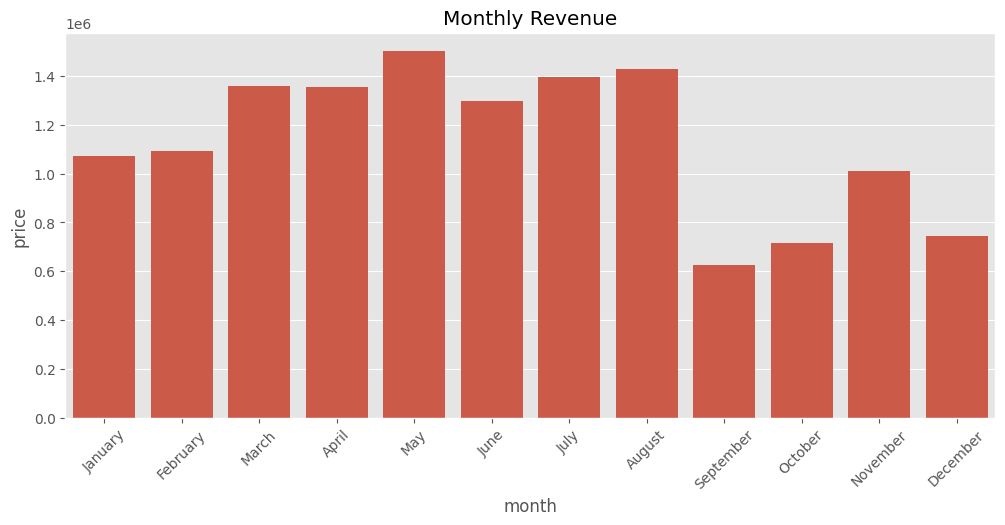

In [39]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')

plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_sales,
    x="month",
    y="price"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue")

plt.show()

In [37]:
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
0000f46a3911fa3c0805444483337064,542,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
0004aac84e0df4da2b147fca70cf8255,293,1,180.00


In [38]:
rfm.describe()

,Recency,Frequency,Monetary
count,95420.000000,95420.000000,95420.000000
mean,243.600377,1.034018,142.440198
std,153.160320,0.211234,217.656355
min,1.000000,1.000000,0.850000
25%,119.000000,1.000000,47.900000
50%,224.000000,1.000000,89.900000
75%,353.000000,1.000000,155.000000
max,729.000000,16.000000,13440.000000


In [40]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

In [41]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

In [42]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

In [43]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,4,1,4
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,4,1,1
0000f46a3911fa3c0805444483337064,542,1,69.00,1,1,2
0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,2,1,1
0004aac84e0df4da2b147fca70cf8255,293,1,180.00,2,1,5


In [44]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [45]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [46]:
def customer_segment(score):
    if score >= 13:
        return "High Value"
    elif score >= 9:
        return "Loyal"
    elif score >= 6:
        return "At Risk"
    else:
        return "Lost"

In [47]:
rfm["Segment"] = rfm["RFM_Score"].apply(customer_segment)

In [48]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
customer_unique_id,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,4,1,4,9,Loyal
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,4,1,1,6,At Risk
0000f46a3911fa3c0805444483337064,542,1,69.00,1,1,2,4,Lost
0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,2,1,1,4,Lost
0004aac84e0df4da2b147fca70cf8255,293,1,180.00,2,1,5,8,At Risk


In [49]:
rfm["Segment"].value_counts()

Segment
Loyal         46297
At Risk       32864
Lost           8157
High Value     8102
Name: count, dtype: int64

In [50]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Segment
Loyal         7924891.56
At Risk       2896737.62
High Value    2435478.50
Lost           334536.02
Name: Monetary, dtype: float64

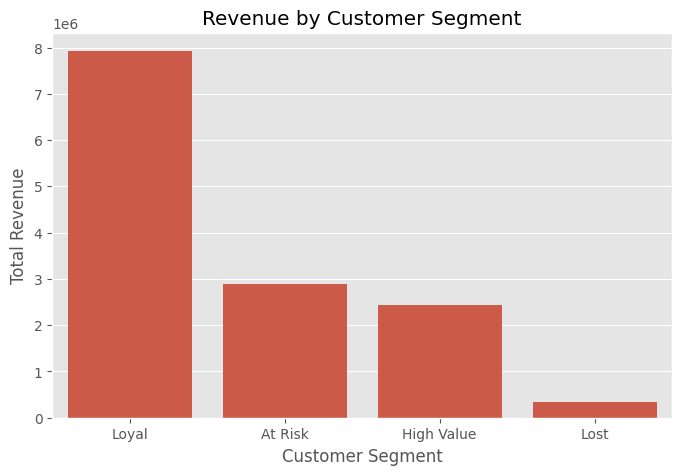

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_revenue.index,
    y=segment_revenue.values
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

In [52]:
monthly_orders = (
    merged
    .groupby(
        merged["order_purchase_timestamp"].dt.to_period("M")
    )
    .size()
)

In [53]:
monthly_orders.index = monthly_orders.index.to_timestamp()

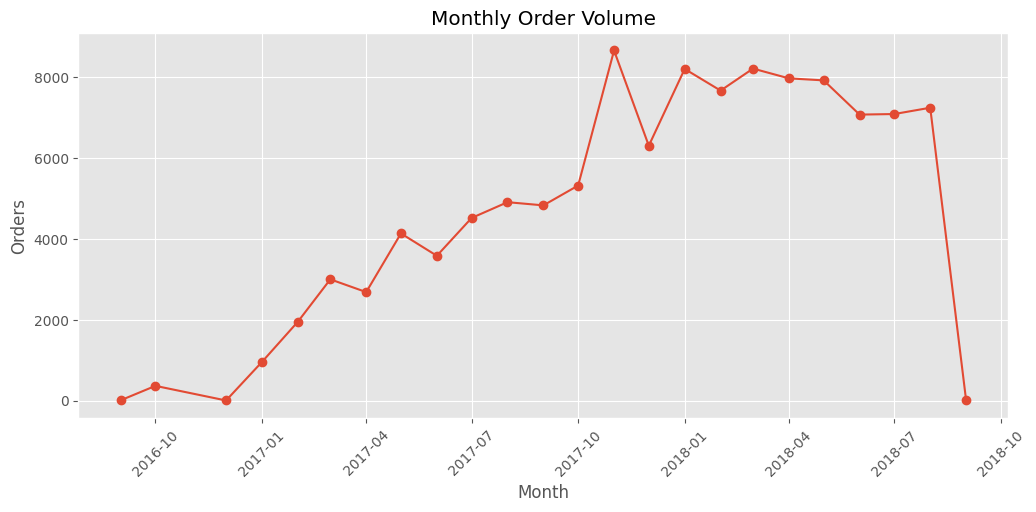

In [54]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

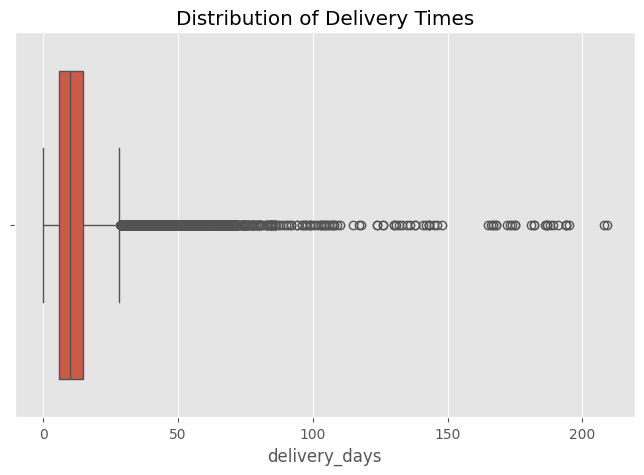

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="delivery_days"
)

plt.title("Distribution of Delivery Times")

plt.show()


In [56]:
top_states = (
    merged.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

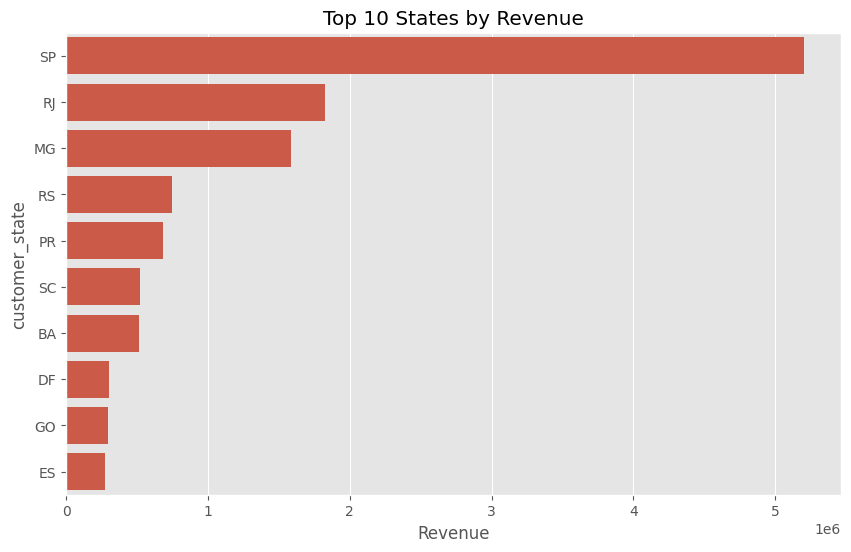

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Revenue")

plt.xlabel("Revenue")

plt.show()